In [14]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(f"Train: {train_images.shape} | Test: {test_images.shape}")

Train: (60000, 28, 28) | Test: (10000, 28, 28)


In [15]:
X_train = train_images.reshape(-1, 784).astype("float32") / 255.0
X_test  = test_images.reshape(-1, 784).astype("float32") / 255.0

In [16]:
mlp_model = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(784,)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
mlp_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
mlp_model.fit(X_train, train_labels, epochs=10, batch_size=256, validation_split=0.1, verbose=0)

test_loss, test_acc = mlp_model.evaluate(X_test, test_labels, verbose=0)
print(f"MLP Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MLP Test Accuracy: 0.9777


## CNN Model

A Convolutional Neural Network to push accuracy above the MLP baseline.

In [17]:
# Reshape for CNN: (samples, 28, 28, 1)
X_train_cnn = train_images.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test_cnn  = test_images.reshape(-1, 28, 28, 1).astype("float32") / 255.0

cnn_model = keras.Sequential([
    keras.Input(shape=(28,28,1)),
keras.layers.Conv2D(32, (3,3), activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax"),
], name="MNIST_CNN")

cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_cnn, train_labels,
    epochs=10, batch_size=256,
    validation_split=0.1, verbose=1,
)

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.8660 - loss: 0.4411 - val_accuracy: 0.9737 - val_loss: 0.0893
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.9626 - loss: 0.1252 - val_accuracy: 0.9843 - val_loss: 0.0538
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.9740 - loss: 0.0880 - val_accuracy: 0.9872 - val_loss: 0.0424
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.9800 - loss: 0.0682 - val_accuracy: 0.9865 - val_loss: 0.0431
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.9822 - loss: 0.0602 - val_accuracy: 0.9867 - val_loss: 0.0406
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.9842 - loss: 0.0522 - val_accuracy: 0.9897 - val_loss: 0.0350
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.9850 - loss: 0.0472 - val_accuracy: 0.9898 - val_loss: 0.0348
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.9880 - loss: 0

In [18]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, test_labels, verbose=0)
print(f"CNN Test Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)")
print(f"CNN Test Loss: {cnn_loss:.4f}")

CNN Test Accuracy: 0.9907 (99.07%)
CNN Test Loss: 0.0300


## Model Comparison — MLP vs CNN vs SVM

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

# SVM on a subset (full 60k is too slow for SVM)
SAMPLE = 5000
X_svm_train, y_svm_train = X_train[:SAMPLE], train_labels[:SAMPLE]

svm_model = SVC(kernel="rbf", gamma="scale")
t0 = time.time()
svm_model.fit(X_svm_train, y_svm_train)
svm_pred = svm_model.predict(X_test[:2000])
svm_acc = accuracy_score(test_labels[:2000], svm_pred)
svm_time = time.time() - t0

print(f"SVM (trained on {SAMPLE} samples) Accuracy: {svm_acc:.4f} | Time: {svm_time:.1f}s")

SVM (trained on 5000 samples) Accuracy: 0.9295 | Time: 4.1s


Model  Test Accuracy                        Notes
  MLP         0.9777            Dense layers only
  CNN         0.9907             Conv2D + pooling
  SVM         0.9295 Trained on 5000 samples only


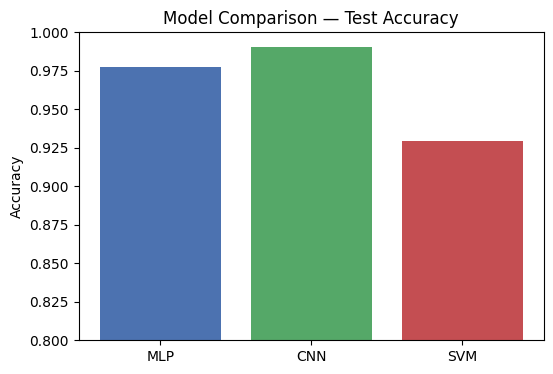

In [20]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["MLP", "CNN", "SVM"],
    "Test Accuracy": [test_acc, cnn_acc, svm_acc],
    "Notes": ["Dense layers only", "Conv2D + pooling", f"Trained on {SAMPLE} samples only"]
})
print(comparison.to_string(index=False))

plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["Test Accuracy"], color=["#4C72B0","#55A868","#C44E52"])
plt.title("Model Comparison — Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

## Robustness Test — Noisy Data

Evaluating model performance on artificially corrupted images to simulate real-world conditions.

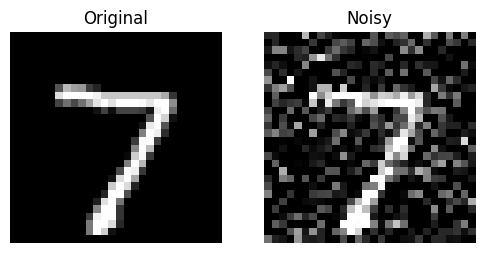

CNN Accuracy on noisy data: 0.9718 (97.18%)
Accuracy drop: 1.89 points


In [21]:
def add_noise(images, noise_factor=0.3):
    noisy = images + noise_factor * np.random.normal(0, 1, images.shape)
    return np.clip(noisy, 0, 1)

X_test_noisy = add_noise(X_test_cnn)

# Visualize one example
fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(X_test_cnn[0].reshape(28,28), cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(X_test_noisy[0].reshape(28,28), cmap="gray"); axes[1].set_title("Noisy"); axes[1].axis("off")
plt.show()

noisy_loss, noisy_acc = cnn_model.evaluate(X_test_noisy, test_labels, verbose=0)
print(f"CNN Accuracy on noisy data: {noisy_acc:.4f} ({noisy_acc*100:.2f}%)")
print(f"Accuracy drop: {(cnn_acc - noisy_acc)*100:.2f} points")